# Chatbot Evaluation

Chatbot evaluation is the process of measuring how well a chatbot responds to user queries.

In this notebook, we will learn how to:

1. Set up LangSmith for evaluation
2. Create an evaluation dataset
3. Build a chatbot using Groq
4. Define evaluation criteria
5. Use an LLM as a judge
6. Run evaluations using LangSmith
7. Analyze the evaluation results

## Setup and Configuration

### Import Required Libraries

In [5]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq
from langsmith import Client

### Environment Variables

In [6]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"

### Initialize LangSmith

In [13]:
client = Client()

### Initialize Groq

In [12]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

## Create Evaluation Dataset - Gathering Data Points
For LangSmith evaluation, we need examples containing questions and expected answers.

In [14]:
dataset_name = "Chatbot Evaluation"

dataset = client.create_dataset(
    dataset_name
)

# Add test cases to the evaluation dataset
client.create_examples(
    dataset_id=dataset.id,
    examples=[
        {
            "inputs": {
                "question": "What is LangChain?"
            },
            "outputs": {
                "answer": "A framework for building LLM applications"
            },
        },
        {
            "inputs": {
                "question": "What is LangSmith?"
            },
            "outputs": {
                "answer": "A platform for observing and evaluating LLM applications"
            },
        },
        {
            "inputs": {
                "question": "What is OpenAI?"
            },
            "outputs": {
                "answer": "A company that creates Large Language Models"
            },
        },
        {
            "inputs": {
                "question": "What is Google?"
            },
            "outputs": {
                "answer": "A technology company known for search"
            },
        },
        {
            "inputs": {
                "question": "What is Mistral?"
            },
            "outputs": {
                "answer": "A company that creates Large Language Models"
            },
        },
    ],
)

{'example_ids': ['c55de693-dfa6-40bc-abb8-796f40100ca7',
  'eb44fefa-ac3e-4762-8d33-5ca0dc2ddfef',
  '09daf90d-6981-4e08-b2e4-7112727a7b0a',
  '57c71bdd-ad75-47a1-bd8f-9f9025f518af',
  'd38a0ec1-e705-4f07-a32b-7333c283580a'],
 'count': 5,
 'as_of': '2026-10-08T07:26:09.190375297Z'}

## Define Evaluation Metrics (LLM as a Judge)

### Initialize Groq Client

In [16]:
from groq import Groq

groq_client = Groq()

### Define Evaluation Instructions

In [17]:
eval_instructions = (
    "You are an expert professor specialized in grading students' answers to questions."
)

### Define Correctness Metric

In [18]:
def correctness(
    inputs: dict,
    outputs: dict,
    reference_outputs: dict
) -> bool:

    user_content = f"""
You are grading the following question:
{inputs['question']}

Here is the real answer:
{reference_outputs['answer']}

You are grading the following predicted answer:
{outputs['response']}

Respond with CORRECT or INCORRECT:

Grade:
"""

    response = groq_client.chat.completions.create(
        model="openai/gpt-oss-120b",
        temperature=0,
        messages=[
            {
                "role": "system",
                "content": eval_instructions
            },
            {
                "role": "user",
                "content": user_content
            }
        ]
    ).choices[0].message.content

    return response.strip() == "CORRECT"

### Define Concision Metric
Checks whether the actual output is less than 2× the length of the expected result.

In [19]:
def concision(outputs: dict, reference_outputs: dict) -> bool:
    return int(
        len(outputs["response"]) < 2 * len(reference_outputs["answer"])
    )

## Run Evaluations

### Define Default Instructions

In [20]:
default_instructions = (
    "Respond to the users question in a short, concise manner (one short sentence)."
)

### Define the Chatbot Application

In [21]:
def my_app(
    question: str,
    model: str = "openai/gpt-oss-120b",
    instructions: str = default_instructions
) -> str:

    return groq_client.chat.completions.create(
        model=model,
        temperature=0,
        messages=[
            {"role": "system", "content": instructions},
            {"role": "user", "content": question},
        ],
    ).choices[0].message.content

### Call my_app for Every Data Point

In [22]:
def ls_target(inputs: str) -> dict:
    return {"response": my_app(inputs["question"])}

### Run Evaluation

In [23]:
experiment_results = client.evaluate(
    ls_target,                  # Your AI system
    data=dataset_name,
    evaluators=[correctness, concision],
    experiment_prefix="openai/gpt-oss-120b-chatbot"
)

View the evaluation results for experiment: 'openai/gpt-oss-120b-chatbot-f20f71a7' at:
https://smith.langchain.com/o/c899d496-c0ba-43c2-9aec-18f4af9446ab/datasets/ab6f4f95-b06c-4028-aee5-7d4c8b4bee46/compare?selectedSessions=a82732be-e13a-4251-bf0a-c58e082387bd




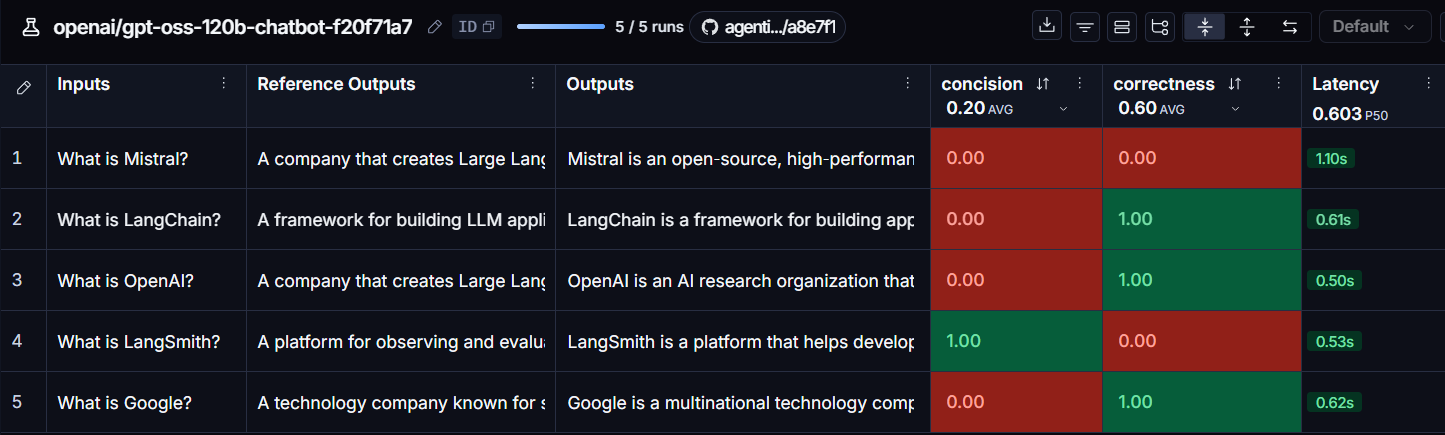

### Run Evaluation with Another Model

In [24]:
def ls_target(inputs: str) -> dict:
    return {"response": my_app(
        inputs["question"],
        model="openai/gpt-oss-20b"
    )}

experiment_results = client.evaluate(
    ls_target,                  # Your AI system
    data=dataset_name,
    evaluators=[correctness, concision],
    experiment_prefix="openai/gpt-oss-20b-chatbot"
)

View the evaluation results for experiment: 'openai/gpt-oss-20b-chatbot-4abe6368' at:
https://smith.langchain.com/o/c899d496-c0ba-43c2-9aec-18f4af9446ab/datasets/ab6f4f95-b06c-4028-aee5-7d4c8b4bee46/compare?selectedSessions=9ce4d4ec-385e-4cd7-91aa-a35529e5dd2e




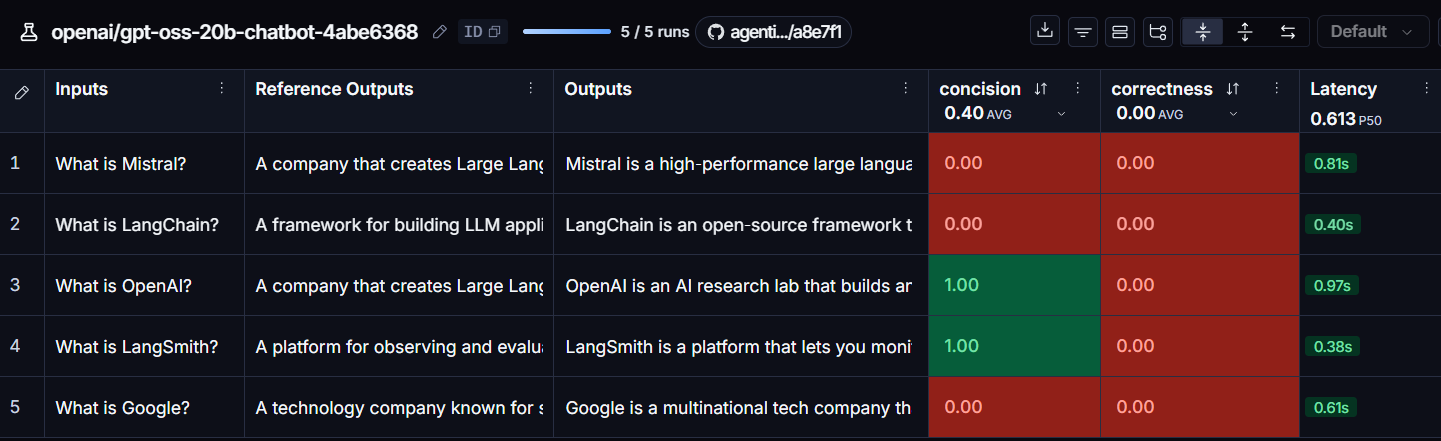